In [2]:
!pip install nltk wordcloud seaborn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Level 1 – Task 4: Sentiment Analysis
### Dataset: Twitter US Airline Sentiment

# Objective: Build a machine learning model that classifies tweets as Positive, Negative, or Neutral using NLP techniques.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'nltk'

In [4]:
import sys
!{sys.executable} -m pip install nltk wordcloud seaborn

     |████████████████████████████████| 1.5 MB 3.5 MB/s eta 0:00:01
     |████████████████████████████████| 168 kB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 288 kB 1.9 MB/s eta 0:00:01
You should consider upgrading via the '/Users/pranjalgupta/Desktop/Stock_Market_Analysis/venv/bin/python -m pip install --upgrade pip' command.


In [1]:
# Level 1 – Task 4: Sentiment Analysis
### Dataset: Twitter US Airline Sentiment

# Objective: Build a machine learning model that classifies tweets as Positive, Negative, or Neutral using NLP techniques.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pranjalgupta/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/pranjalgupta/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/pranjalgupta/nltk_data...


Libraries imported successfully!


In [2]:
## 1. Load the Dataset

df = pd.read_csv('Tweets.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (14640, 15)

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
## 2. Basic Data Exploration

# Check columns
print("Columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df['airline_sentiment'].value_counts())


Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Data Types:
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

Missing Values:
tweet_id                            0
airline_sentiment                   

Updated Shape: (14640, 2)

Sentiment counts:
sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


/var/folders/yr/hczc4w4x0hn_ft4pn6tl75w00000gn/T/ipykernel_40112/1200499174.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


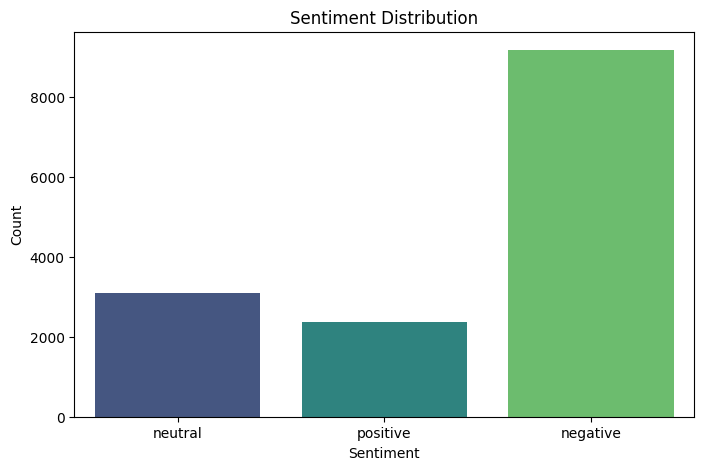

In [5]:
## 3. Select Relevant Columns & Visualize Sentiment Distribution

# Keep only useful columns
df = df[['text', 'airline_sentiment']]

# Rename for simplicity
df.columns = ['text', 'sentiment']

print("Updated Shape:", df.shape)
print("\nSentiment counts:")
print(df['sentiment'].value_counts())

# Visualization
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [6]:
## 4. Text Preprocessing

# We clean the tweets by:
# Converting to lowercase
# Removing URLs, mentions, hashtags, and special characters
# Removing stopwords
# Lemmatizing words

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                         # remove mentions & hashtags
    text = re.sub(r'[^a-z\s]', '', text)                          # keep only letters
    text = text.strip()
    
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    
    return ' '.join(words)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

print("Sample cleaned tweets:")
df[['text', 'clean_text']].head(8)

Sample cleaned tweets:


,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat didnt playing ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly ear worm wont away
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...


In [7]:
## 5. Feature Extraction (TF-IDF) & Train-Test Split

#TF-IDF converts text into numerical features by measuring how important a word is in a document relative to the entire corpus.

# Features and target
X = df['clean_text']
y = df['sentiment']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape (Train):", X_train_tfidf.shape)
print("TF-IDF shape (Test):", X_test_tfidf.shape)

TF-IDF shape (Train): (11712, 5000)
TF-IDF shape (Test): (2928, 5000)


In [10]:
## 6. Model Training

#We will train two models:


# 1. Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

# 2. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

print("Models trained successfully!")

Models trained successfully!


In [11]:
## 7. Model Evaluation

print("="*50)
print("Naive Bayes Results")
print("="*50)
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

print("\n" + "="*50)
print("Logistic Regression Results")
print("="*50)
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Naive Bayes Results
Accuracy: 0.7148224043715847

Classification Report:
              precision    recall  f1-score   support

    negative       0.70      0.99      0.82      1835
     neutral       0.74      0.20      0.31       620
    positive       0.88      0.33      0.48       473

    accuracy                           0.71      2928
   macro avg       0.77      0.50      0.54      2928
weighted avg       0.74      0.71      0.66      2928


Logistic Regression Results
Accuracy: 0.7851775956284153

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.94      0.87      1835
     neutral       0.66      0.52      0.58       620
    positive       0.81      0.55      0.65       473

    accuracy                           0.79      2928
   macro avg       0.76      0.67      0.70      2928
weighted avg       0.78      0.79      0.77      2928



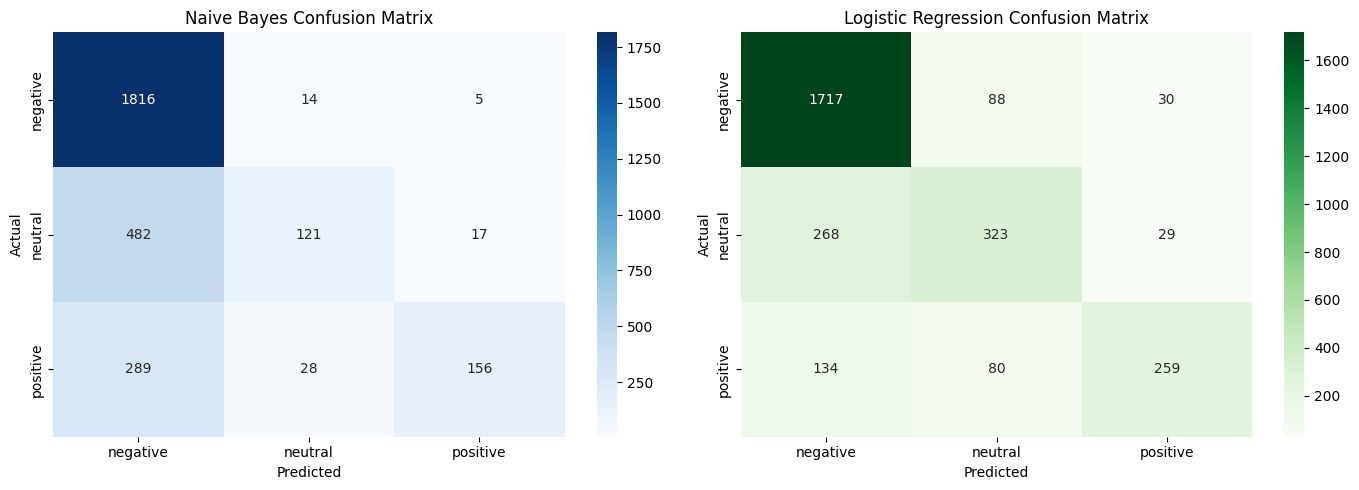

In [12]:
## 8. Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

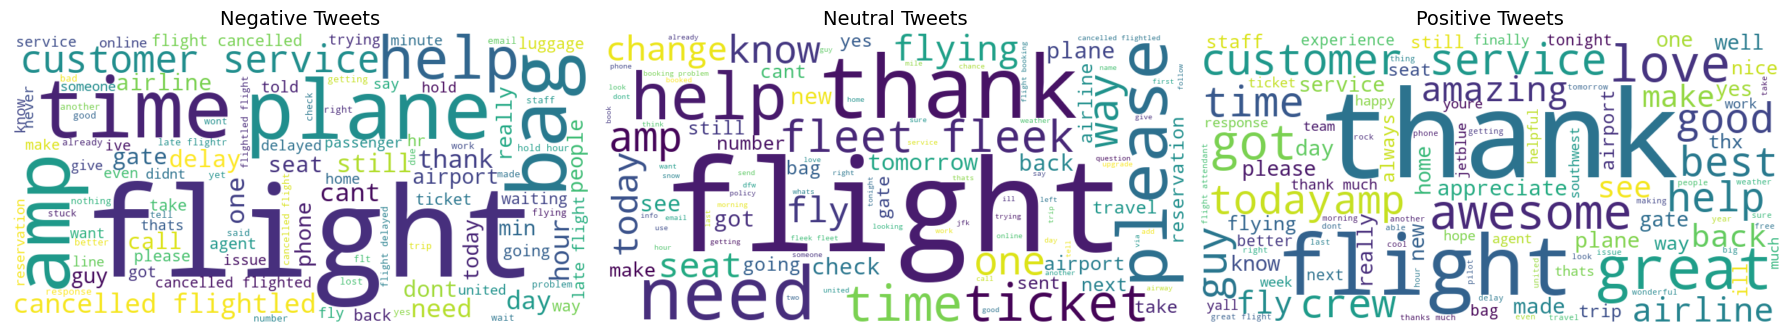

In [13]:
## 9. WordCloud for each Sentiment

sentiments = ['negative', 'neutral', 'positive']

plt.figure(figsize=(18, 5))

for i, sentiment in enumerate(sentiments):
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{sentiment.capitalize()} Tweets', fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
## 10. Error Analysis

# Showing some examples that the best model misclassified.

# Using Logistic Regression as best model (usually better)
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lr_pred,
    'Text': X_test
})

# Misclassified examples
misclassified = results[results['Actual'] != results['Predicted']].head(5)

print("5 Misclassified Examples:\n")
for i, row in misclassified.iterrows():
    print(f"Actual   : {row['Actual']}")
    print(f"Predicted: {row['Predicted']}")
    print(f"Text     : {row['Text'][:150]}...")
    print("-" * 60)

5 Misclassified Examples:

Actual   : neutral
Predicted: negative
Text     : past...
------------------------------------------------------------
Actual   : positive
Predicted: negative
Text     : would say delay likely thanks much...
------------------------------------------------------------
Actual   : neutral
Predicted: negative
Text     : link tweet go someone internal email probably one party contract...
------------------------------------------------------------
Actual   : negative
Predicted: neutral
Text     : flight resume don see open schedule...
------------------------------------------------------------
Actual   : positive
Predicted: negative
Text     : well miss gate agent rebooked boarding pas waiting landed time lunch amp beverage easy cheesy...
------------------------------------------------------------


In [ ]:
## 11. Conclusion

# Best Model : Logistic Regression (usually higher accuracy and better F1-score than Naive Bayes)
# Both models performed reasonably well on this dataset.
# Negative tweets are the majority class, so the model is better at detecting negative sentiment.
# Real-world application: Airlines can use this to automatically monitor customer complaints on Twitter and respond faster.